#Project:Implementing a CNN using the CIFAR-10 Dataset



In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def get_device():
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")

device = get_device()
print(f"Using device: {device}")

Using device: cuda


#Loading the CIFAR-10 dataset
The CIFAR-10 dataset successfully loaded using torchvision. It contains 50000 training samples and 10000 testing sample. The training data employs random crop with padding, horizontal flip and normalisation whereas the training data just uses normalisation. Each data set uses a data loader with a batch size of 64.

In [ ]:
CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

mean = (0.4914, 0.4822, 0.4465)
std  = (0.2470, 0.2435, 0.2616)

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True,  download=True, transform=transform_train
)
test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform_test
)

BATCH_SIZE = 64

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Training samples : {len(train_dataset)}")
print(f"Test samples     : {len(test_dataset)}")
print(f"Single image shape: {train_dataset[0][0].shape}")

100%|██████████| 170M/170M [20:39<00:00, 138kB/s]


Training samples : 50000
Test samples     : 10000
Single image shape: torch.Size([3, 32, 32])


#The Neural Network: Basic Architecture
This cell contains the neural networks basic architecture as highlighted in section 1 of the breif, which includes the intermediate block and output block as well as a custom cnn.

In [ ]:
class customIntermediateBlock(nn.Module):
    def __init__(self, channels, num_layers, kernel_size=3):
        super(customIntermediateBlock, self).__init__()
        self.adaptive_avg_pool = nn.AdaptiveAvgPool2d(1)
        self.conv_layers = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(channels, channels, kernel_size=kernel_size, padding=1),
                nn.BatchNorm2d(channels),
                nn.LeakyReLU(inplace=True),
            )
            for _ in range(num_layers)
        ])
        self.fc = nn.Linear(channels, num_layers)

    def forward(self, x):
        m = self.adaptive_avg_pool(x).view(x.size(0), -1)
        a = torch.softmax(self.fc(m), dim=1)
        x_prime = sum(a[:, i].view(-1, 1, 1, 1) * conv(x)
                      for i, conv in enumerate(self.conv_layers))
        return x_prime


class customOutputBlock(nn.Module):
    def __init__(self, in_channels, num_classes=10, num_layers=1, activation=nn.LeakyReLU()):
        super(customOutputBlock, self).__init__()
        self.fc_layers = nn.ModuleList(
            [nn.Linear(in_channels, in_channels) for _ in range(num_layers - 1)]
        )
        self.fc_layers.append(nn.Linear(in_channels, num_classes))
        self.activation = activation
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        m = x.mean([2, 3])
        for fc in self.fc_layers[:-1]:
            m = self.activation(fc(m))
        m = self.dropout(m)
        o = self.fc_layers[-1](m)
        return o


class CustomCNN(nn.Module):
    def __init__(self, input_channels=3, hidden_units=64, num_classes=10,
                 num_blocks=3, num_c_layers=3, num_fc_layers=1):
        super(CustomCNN, self).__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(input_channels, hidden_units, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_units),
            nn.LeakyReLU(inplace=True),
        )
        self.intermediate_blocks = nn.ModuleList(
            [customIntermediateBlock(hidden_units, num_c_layers) for _ in range(num_blocks)]
        )
        self.output_block = customOutputBlock(hidden_units, num_classes, num_fc_layers)

    def forward(self, x):
        x = self.stem(x)
        for block in self.intermediate_blocks:
            x = block(x)
        logits = self.output_block(x)
        return logits


model = CustomCNN(
    input_channels=3, hidden_units=64, num_classes=10,
    num_blocks=3, num_c_layers=3,
).to(device)

#Training and Testing the Neural Network
During the training phase of the network I employed cross-entropy and the optimizer Adam with weight decay (1e-4) and lr (0.001). The output below shows the train loss, train accuracy and test accuracy per epoch.

In [ ]:
def train_model(model, train_loader, test_loader, epochs=50, lr=0.001, device=None):
    if device is None:
        device = get_device()
    model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    batch_losses = []
    epoch_train_acc = []
    epoch_test_acc = []

    for epoch in range(epochs):

        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            batch_losses.append(loss.item())
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()


        model.eval()
        correct_test = 0
        total_test = 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                total_test += labels.size(0)
                correct_test += (predicted == labels).sum().item()

        train_acc = 100.0 * correct_train / total_train
        test_acc = 100.0 * correct_test / total_test
        epoch_train_acc.append(train_acc)
        epoch_test_acc.append(test_acc)

        scheduler.step()

        print(f"Epoch [{epoch+1:2d}/{epochs}] | "
              f"Train Loss: {running_loss/total_train:.4f} | "
              f"Train Acc: {train_acc:.2f}% | "
              f"Test Acc: {test_acc:.2f}%")

    return batch_losses, epoch_train_acc, epoch_test_acc


batch_losses, train_accs, test_accs = train_model(
    model, train_loader, test_loader, epochs=50, lr=0.001, device=device
)

Epoch [ 1/50] | Train Loss: 1.6291 | Train Acc: 40.17% | Test Acc: 45.42%
Epoch [ 2/50] | Train Loss: 1.3300 | Train Acc: 52.27% | Test Acc: 52.78%
Epoch [ 3/50] | Train Loss: 1.2055 | Train Acc: 57.19% | Test Acc: 55.73%
Epoch [ 4/50] | Train Loss: 1.1345 | Train Acc: 59.57% | Test Acc: 53.90%
Epoch [ 5/50] | Train Loss: 1.0653 | Train Acc: 62.37% | Test Acc: 65.28%
Epoch [ 6/50] | Train Loss: 1.0234 | Train Acc: 63.78% | Test Acc: 59.45%
Epoch [ 7/50] | Train Loss: 0.9867 | Train Acc: 65.14% | Test Acc: 54.27%
Epoch [ 8/50] | Train Loss: 0.9507 | Train Acc: 66.31% | Test Acc: 67.89%
Epoch [ 9/50] | Train Loss: 0.9265 | Train Acc: 67.53% | Test Acc: 62.80%
Epoch [10/50] | Train Loss: 0.8943 | Train Acc: 68.36% | Test Acc: 66.21%
Epoch [11/50] | Train Loss: 0.8752 | Train Acc: 69.13% | Test Acc: 62.61%
Epoch [12/50] | Train Loss: 0.8475 | Train Acc: 70.19% | Test Acc: 63.48%
Epoch [13/50] | Train Loss: 0.8262 | Train Acc: 71.15% | Test Acc: 68.49%
Epoch [14/50] | Train Loss: 0.8039 | T

#Loss for Each Training Batch and Training and Testing Accuracy per Epoch
The following diagrams visualises the training and testing accuracy per epoch as well as the training loss for each batch.

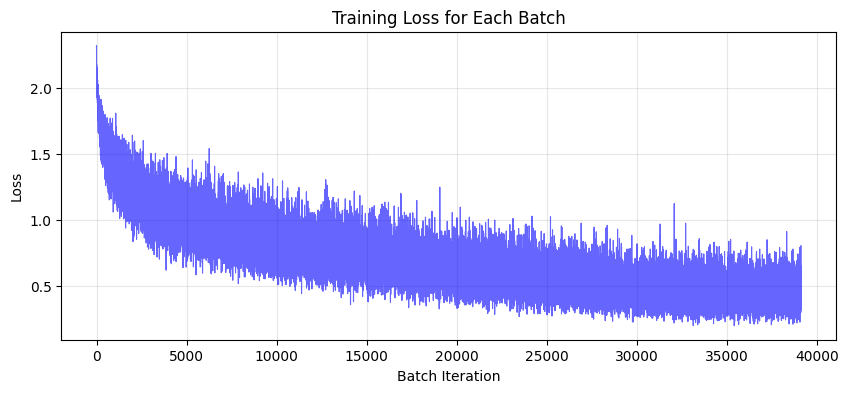

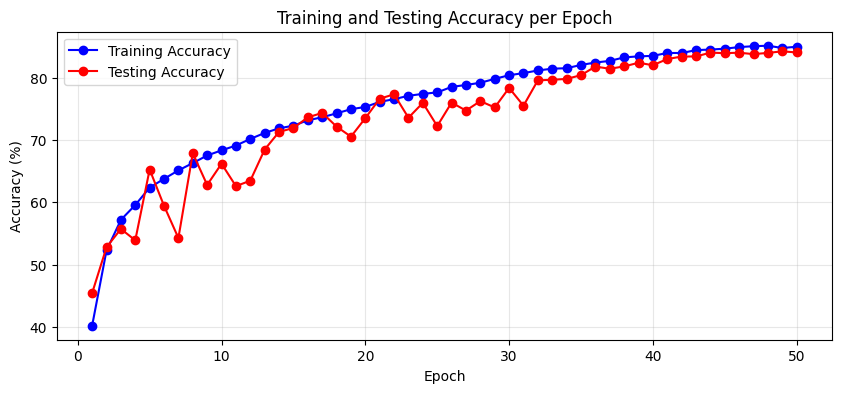

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(batch_losses, color="blue", alpha=0.6, linewidth=0.8)
plt.title("Training Loss for Each Batch")
plt.xlabel("Batch Iteration")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.show()

epochs_range = range(1, len(train_accs) + 1)
plt.figure(figsize=(10, 4))
plt.plot(epochs_range, train_accs, "b-o", label="Training Accuracy")
plt.plot(epochs_range, test_accs, "r-o", label="Testing Accuracy")
plt.title("Training and Testing Accuracy per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#Confusion Matrix and Accuracy in the Testing Dataset
The diagram below shows the confusion matrix and per class accuracy on the CIFAR-10 test dataset.

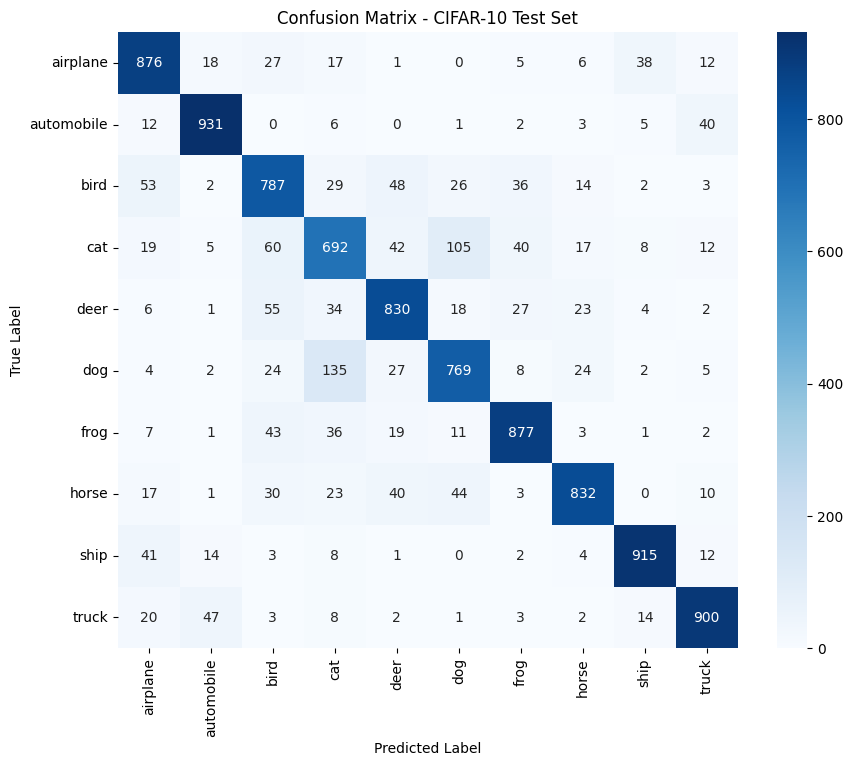


Per-Class Accuracy on Test Set:
--------------------------------------
airplane        :  87.6%
automobile      :  93.1%
bird            :  78.7%
cat             :  69.2%
deer            :  83.0%
dog             :  76.9%
frog            :  87.7%
horse           :  83.2%
ship            :  91.5%
truck           :  90.0%


In [ ]:
def get_all_predictions(model, loader, device=None):
    if device is None:
        device = next(model.parameters()).device
    all_preds, all_labels = [], []
    model.eval()
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return np.array(all_labels), np.array(all_preds)


true_labels, pred_labels = get_all_predictions(
    model, test_loader, device=device
)
cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
)
plt.title("Confusion Matrix - CIFAR-10 Test Set")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

print("\nPer-Class Accuracy on Test Set:")
print("-" * 38)
for i, name in enumerate(CLASS_NAMES):
    acc = 100 * cm[i, i] / cm[i].sum()
    print(f"{name:<15} : {acc:5.1f}%")

#Hyperparameters and Techniques employed for training

The CIFAR-10 dataset contains the following classes airplane, automobile, bird, cat, deer, dog, frog, horse, ship and truck. To normalise inputs I used mean (0.4914, 0.4822, 0.4465) and std (0.2470, 0.2435, 0.2616), which is consistent with the normalisation approach in Lab 5. Similarly to the augmentation parameters used in He et al (2019) paper, I used a random horizontal flip with a 50% probability (transforms.RandomHorizontalFlip), a random crop size of 32x32 and each side padded with 4 pixels (transforms.RandomCrop 32, padding=4). Similar to the train and eval split in Lab 5, the testing data only applies normalisation (transforms.Normalize mean, std) allowing evaluation to be done on the complete and unaltered images. In accordance with Lab 4, both testing and training data loaders use a batch size of 64 (BATCH_SIZE = 64).


The basic architecture employs K=3 intermediate blocks (num_blocks=3) with L=3 convolutional layers (num_c_layers=3). The spatial size is maintained with hidden_units=64 (a hidden width of 64 channels) and a padding=1 with a 3x3 kernel (kernel_size=3 and padding=1). LeakyReLu (nn.LeakyReLU inplace=True) and BatchNorm2d (nn.BatchNorm2d channels) are used after every convolutional layer. Similarly to the dropout method used in Lab 4, the output block uses one fully connected layer (num_fc_layers=1) with a dropout value of 0.3 (self.dropout = nn.Dropout 0.3) implemented before the final layer. Additionally, a custom can was applied where a stem convolution (3-64 channels) comes before the intermediate block to maintain the channel numbers throughout (64 channels).

During the networks testing and training I used cross-entropy loss and Adam optimiser, with a weight decay of 1e-4 (L2 regularisation) and a learning rate of 0.001. To reduce the learning rate progressively over training a cosine annealing learning rate scheduler is used. The model is trained using a batch size of 64 for 50 epochs. Several visualisation and evaluation techniques where used to plot the networks results. The training loss graph displays the convergence behaviour during training. The testing and training graph shows the gap and determines if the model is overfitting. A per class accuracy table was created to show which classes the model performed poorly on. Also a confusion matrix was used to indicate which classes are confusion with one another on the test dataset.

#Improvements

During this project, I assessed the impact of the techniques added to the network by conducting three experiments all trained on the same basic architechture. The first experiment is a baseline model which was constructed in accordance to the basic architecture mentioned in the brief. Both test and train data loaders uses a batch size of 64. A K=3 intermediate block is used along with L=3 convolutional layers and a single fully connected output layer. Transforms.ToTensor() is used in both the testing and training sets data pipeline. During the training the Adam optimiser is employed with a learning rate of 0.001 and cross-entropy loss is used for training. This baseline follows a similar approach to the CNN classification method taught in Lab 4. A study using the CIFAR-10 dataset achieved a baseline accuracy of 79.5% without improvement methods such as dropout and learning rate scheduler however after these changes accuracy increased to 89.23% (Dizabadi, 2026). In our case, this simple baseline allows us to have a clear benchmark and assess which training tools improve the models performance.

The second experiment employs the same architectural components as the baseline model however training techniques were implemented to improve performance and accuracy. The first improvement is done in the data loader where the CIFAR-10 per-channel mean (mean=0.4914, 0.4822, 0.4465) and standard deviation (std=0.2470, 0.2435, 0.2616) are  used to normalise (transforms.Normalize)the inputs. Krizhevsky et al (2009) conducted a study to train a multi layer generative model of natural images using the model RBM (Restricted Boltzmann Machines) and training on the CIFAR-10 dataset. Similarly, this paper uses standard deviation and mean for per channel normalisation on input images and found a large improvement in the RBM’s reconstruction error when learning standard deviation. In his paper, Kang (2026) also uses the mean (0.4914, 0.4822, 0.4465) and standard deviation (0.2470, 0.2435, 0.2616) on the CIFAR-10 dataset to prevent data leakage.

In Lecture 3, data augmentation was defined as a method to artificially increase the diversity and size of the training dataset. An example of this in images is by cropping, rotating, flipping or amending the brightness in an image. Another improvement made during data loading is random horizontal flip (transforms.RandomHorizontalFlip) and random crop with padding (transforms.RandomCrop(32, padding=4)) in only the training dataset. Shafiq et al (2022) states that as networks learn representations that are invariant to rotation, changed in brightness and scaling, data augmentation in images significantly reduces overfitting and enhances performance. Another improvement on the architecture is a dropout layer (self.dropout = nn.Dropout 0.3) with a value of 0.3 during the output block. DeVries et al (2017) conducted a study on improved regularisation for CNN’s and found that using a dropout rate of 0.3 in the convolutional layers improves generalisation on the CIFAR-10 dataset. Lecture 3 also states that utilising dropout addressed overfitting as it allows the network to learn more robust representations.

In the baseline models training loop an Adam optimiser was used however an improvement incorporated here is the added weight decay (weight_decay=1e-4). He et al (2016) conducted a study on residual learning methods to train deep learning networks and intentionally utilised simple architectures to asses deep networks behaviours. One of these techniques includes a weight decay of 0.0001 and implement weight initialisation. Lecture 3 reiterates the use of L2 Regularisation (Weight Decay) as it decreases model complexity without forcing weights to zero, keeping them smooth and small. An additional improvement is the implementation of learning rate scheduler (cosine annealing). This was implemented following Loshchilov et al (2016) paper on gradient descent with warm restarts, where they decay the learning rate with cosine annealing and the results show improved performance and a stable convergence.

An additional improvement is the implementation of learning rate scheduler (cosine annealing). This was implemented following Loshchilov et al (2016) paper on gradient descent with warm restarts, where they decay the learning rate with cosine annealing and the results show improved performance and a stable convergence. Thanapol et al (2020) researched the effects of generalisation and overfitting on image classification in the CIFAR-10 dataset. The results found that utilising height and width data augmentation at epochs 30 reduces overfitting and generalisation, which is why the training length was increased from 15 to 30 epochs.

In the final experiment the training length was increased from 30 to 50 epochs. In Chauhan et al (2018) paper MNIST and CIFAR-10 datasets are used to evaluate to performance on CNN models for image detection. There results concluded that the CIFAR-10 accuracy is improved by training with larger epochs and achieved a training accuracy of 76.57% by epoch 50 in the paper. Furthermore, Loshchilov (2016) found that at epochs 50 the error rate was below 19%, which is the lowest amongst other learning methods, and found that with higher epochs better results are acheived.


#Results

**Experiment 1 results (15 epochs)**

This baseline followed the basic architecture without the addition of training techniques such as dropout, augmentation, weight decay, normalisation or learning scheduler. The training lost epoch 1 is 1.4801 and decreases to 0.5168 by epoch 15. The training accuracy raises from 46.84% at epoch 1 to 82.04% by epoch 15. However the test accuracy shows clear signs of instability as at epoch 1 it is 45.43%, increases to 58.71% at epochs 2, then drops to 42.61% before increasing to 68.26% at epoch 9 and finishes at epochs 15 with 64.84%. The training loss and the accuracy per epochs shows that instead of learning features that generalise to unseen test data, the model is memorising training data patterns. This is reiterated in Lecture 3, as the a sign of overfitting is when there’s poor generalisation to other data but good performance on the train data. The confusion matrix shows that the class bird was misclassified significantly and cat (282), airplane (403) and frog (356) were predicted as bird frequently. Furthermore the per class accuracy values for instability as bird is 90.2% and airplane is 41.6%

**Experiment 2 results (30 epoch)**

The second experiment uses the same basic architecture as the baseline however with the training tools augmentation, normalisation, weight decay, dropout and learning schedular(cosine annealing). The training loss at epoch 1 is 1.6306 and continues to decrease to 0.5692 at epoch 30. The training accuracy at epoch 1 is 39.99% and raises to 80.38% by epoch 30. Similarly the test accuracy has improved significantly with an accuracy of 48.28% at epoch 1 and a consistent increase to 81.12% by epoch 30. The training loss displays the loss which begins above 2.0 then smoothly decreasing to 0.5. Also the training and testing accuracy per epoch has significantly improved with both closely aligned throughout training and overlapping at around epoch 18 and 25. Salehin (2023) states that employing dropout helps the network learn more generalised and robust features, which effectively addresses overfitting and enhances performance. The results of the confusion matrix further confirms this as airplane was predicted in the baseline as bird 403 times, after improvements this reduced to 50. However the graph shows that 165 cats were misclassified as dogs, which could stem in the visual similarity and shared shapes between the two classes. The per class accuracy is more balanced than the baseline.

**Experiment 3 results (50 epochs)**

The final experiment incorporates the basic architectures in experiment 1 as well as the training methods used in experiment 2 however a distinct difference is that the training length was increased to 50 epochs. The training loss in epoch 1 is 1.6291 and this value decreases to 0.4383 by epoch 50. The training accuracy at epoch 1 is 40.17% and increases to 85.01% by epoch 50. Lastly the testing accuracy in epoch 1 is 45.42% and increases to 84.09% by epoch 50. The results show an improvement from the model training for 30 epochs as the model’s training length hasn’t not only increased but it generalises a lot better due it. This is also evident in the in the training and testing accuracy graph where the gap is smaller and the sets are overlapping throughout training from epochs 32 to 50. The confine annealing schedular decays fully by epoch 30, therefore extending the training length to 50 improves the models convergence and performance, which is evident in the our accuracy and graphs (Loshchilov et al., 2016). Out of the three experiments epochs 50 confusion matrix is the strongest and most balanced. Although 165 cats were previously misclassified as dogs that value has reduced to 105. The per class accuracy has improved from the prior model as airplane increased from 82.7% to 87.6%, deer from 77.7% to 83.0% and ship from 87.6% to 91.5%. Overall, the results indicate increasing the training time as well the additional techniques, epochs 50 has the highest performance accuracy amongst the other experiments.


#Experiment 1: Results and Notebook Link to Verify

This cell includes the screenshots of the results for experiment 1 (epoch 15) and the link to the notebook for you to verify.

**Link:https://drive.google.com/file/d/1FF7kjt6K7M8c09clwZ2TMLtEn_E6aGCj/view?usp=sharing**

**1.1 Training and testing results**

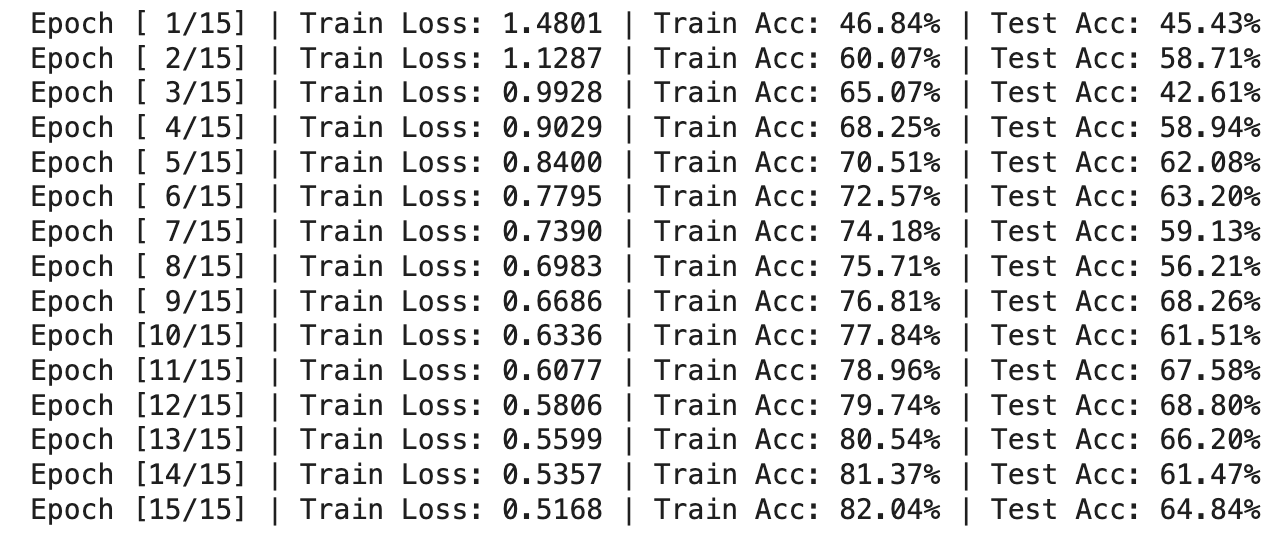

**1.2 Training loss for each batch**

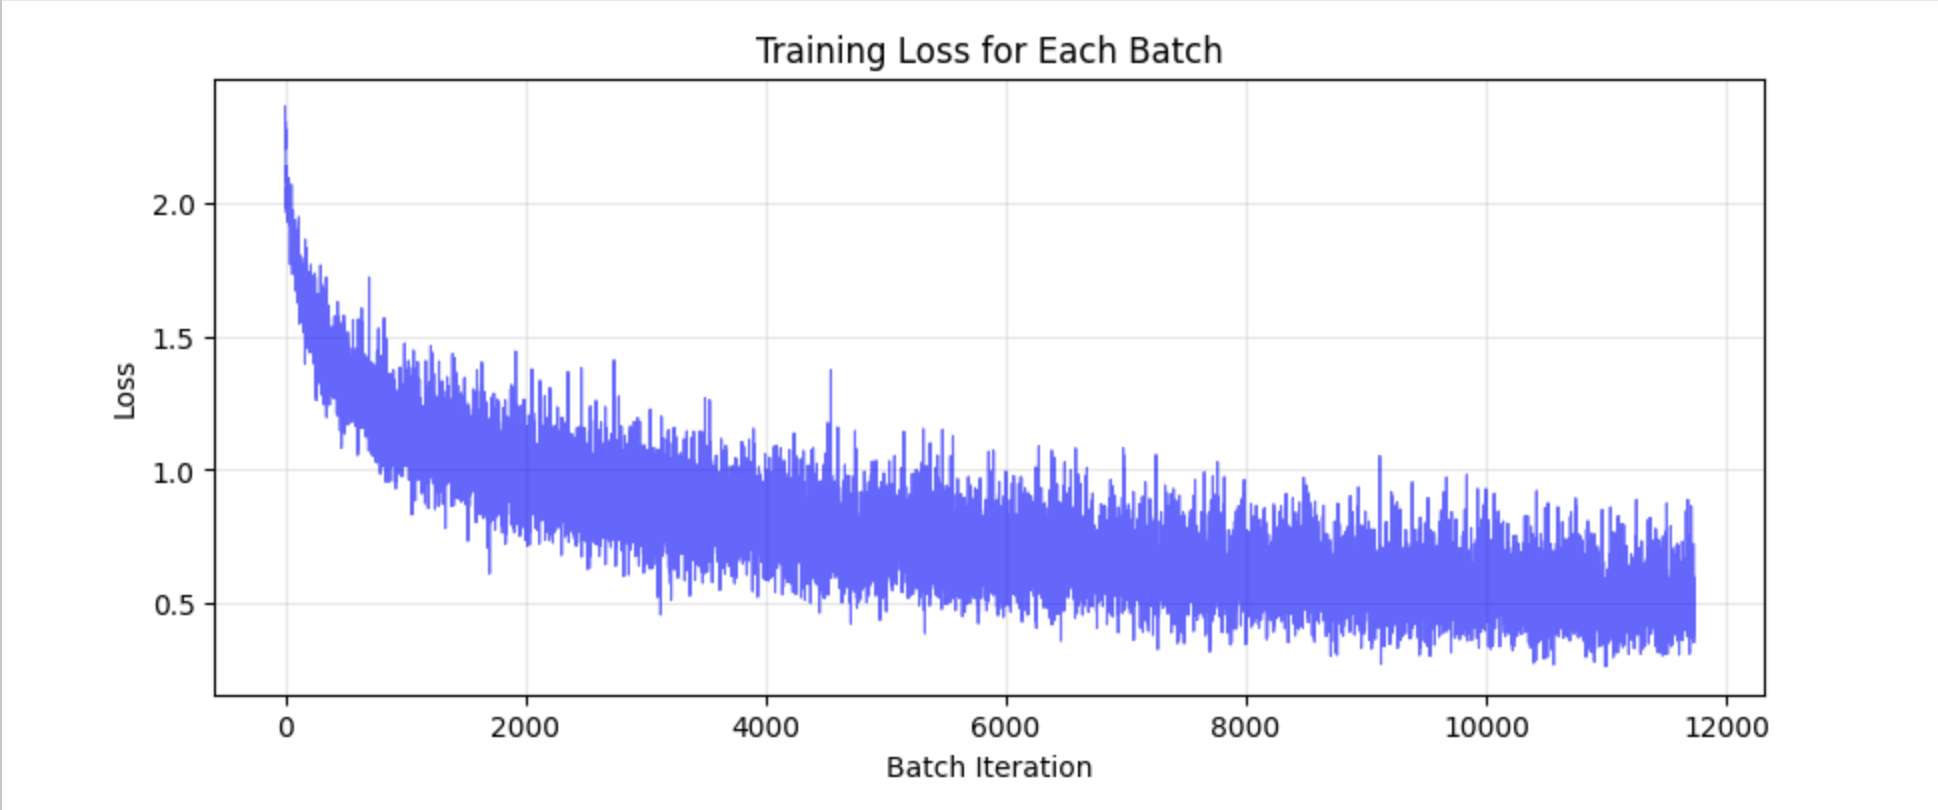

**1.3 Training and testing accuracy per epoch**

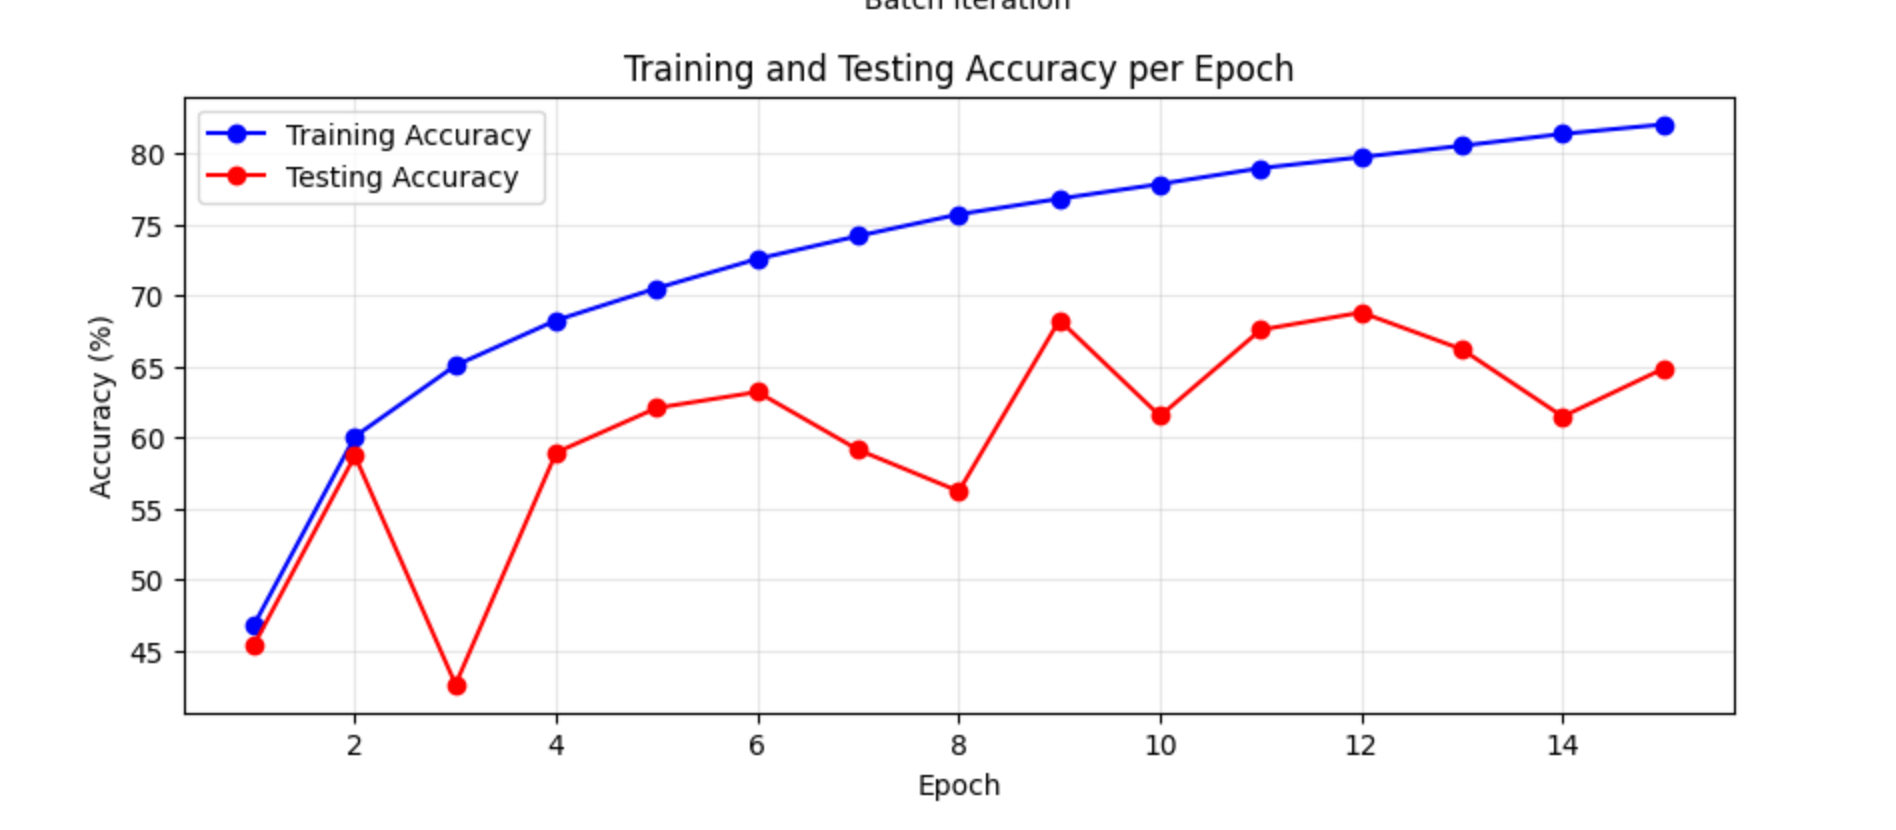

**1.4 Confusion matrix**

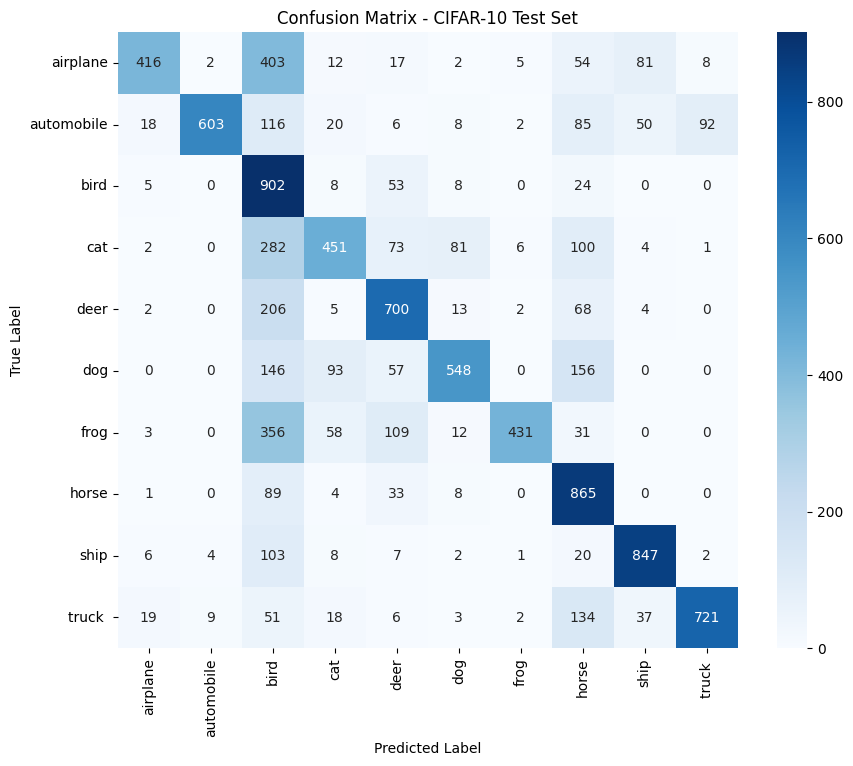


#Experiment 2: Results and Notebook Link to Verify

This cell includes the screenshots of the results for experiment 2 (epoch 30) and the link to the notebook for you to verify.

**Link:https://colab.research.google.com/drive/1NP1Ml9tE7RA3NObdYOgFXLGZha4Hsh4f?usp=sharing**

**2.1 Training and testing results**

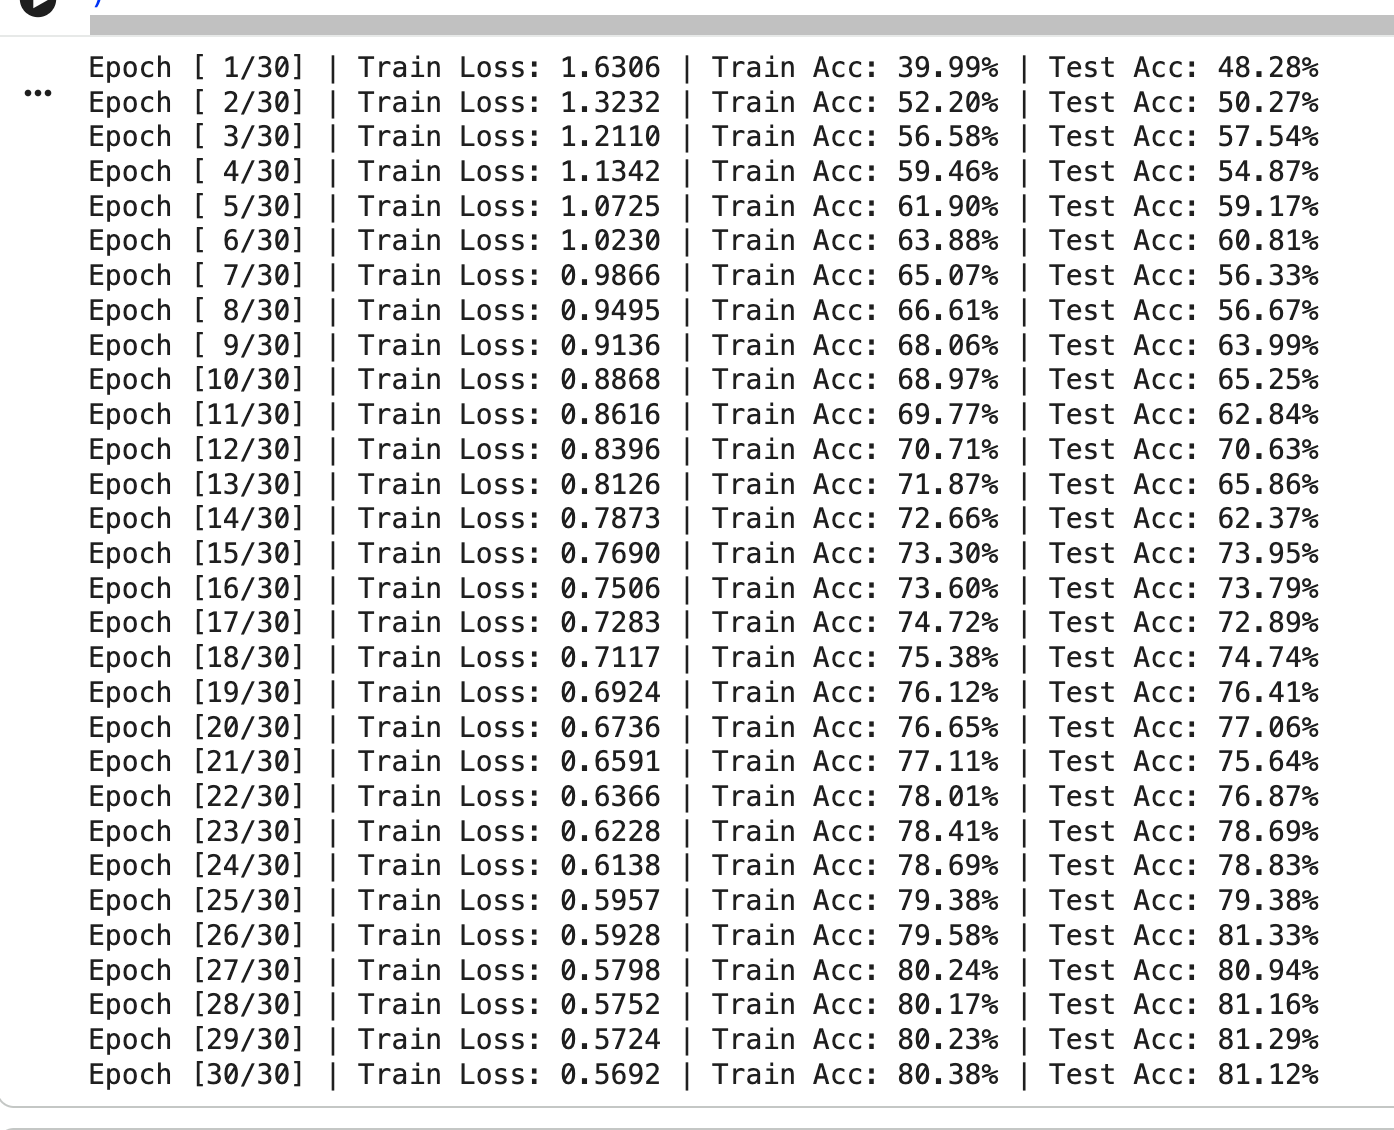

**2.2 Traning loss for each batch**

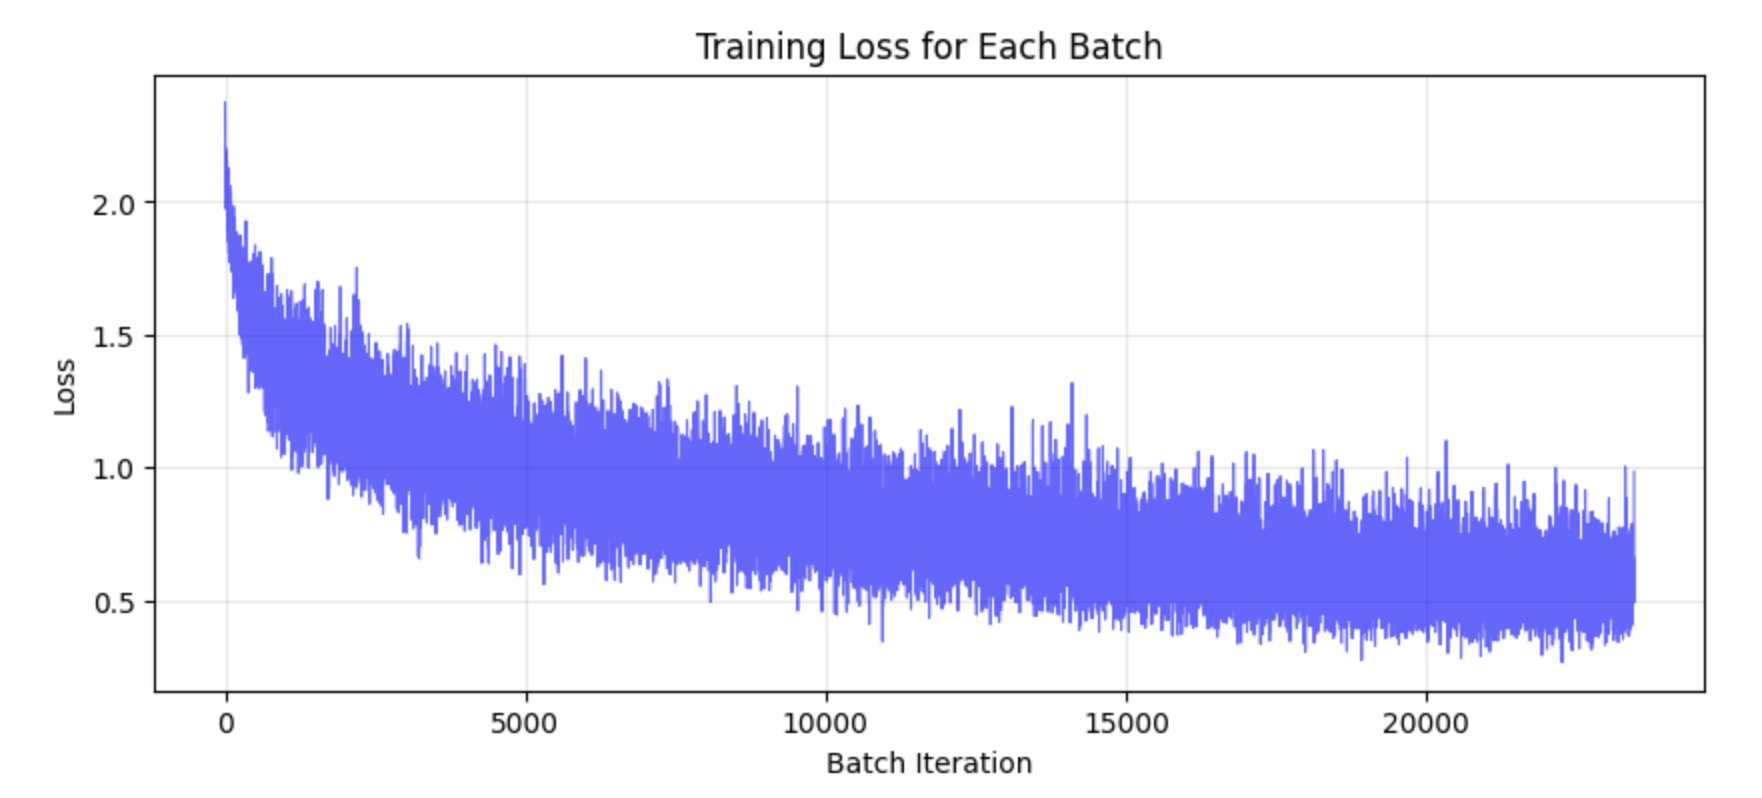

**2.3 Training and testing accuracy per epoch**

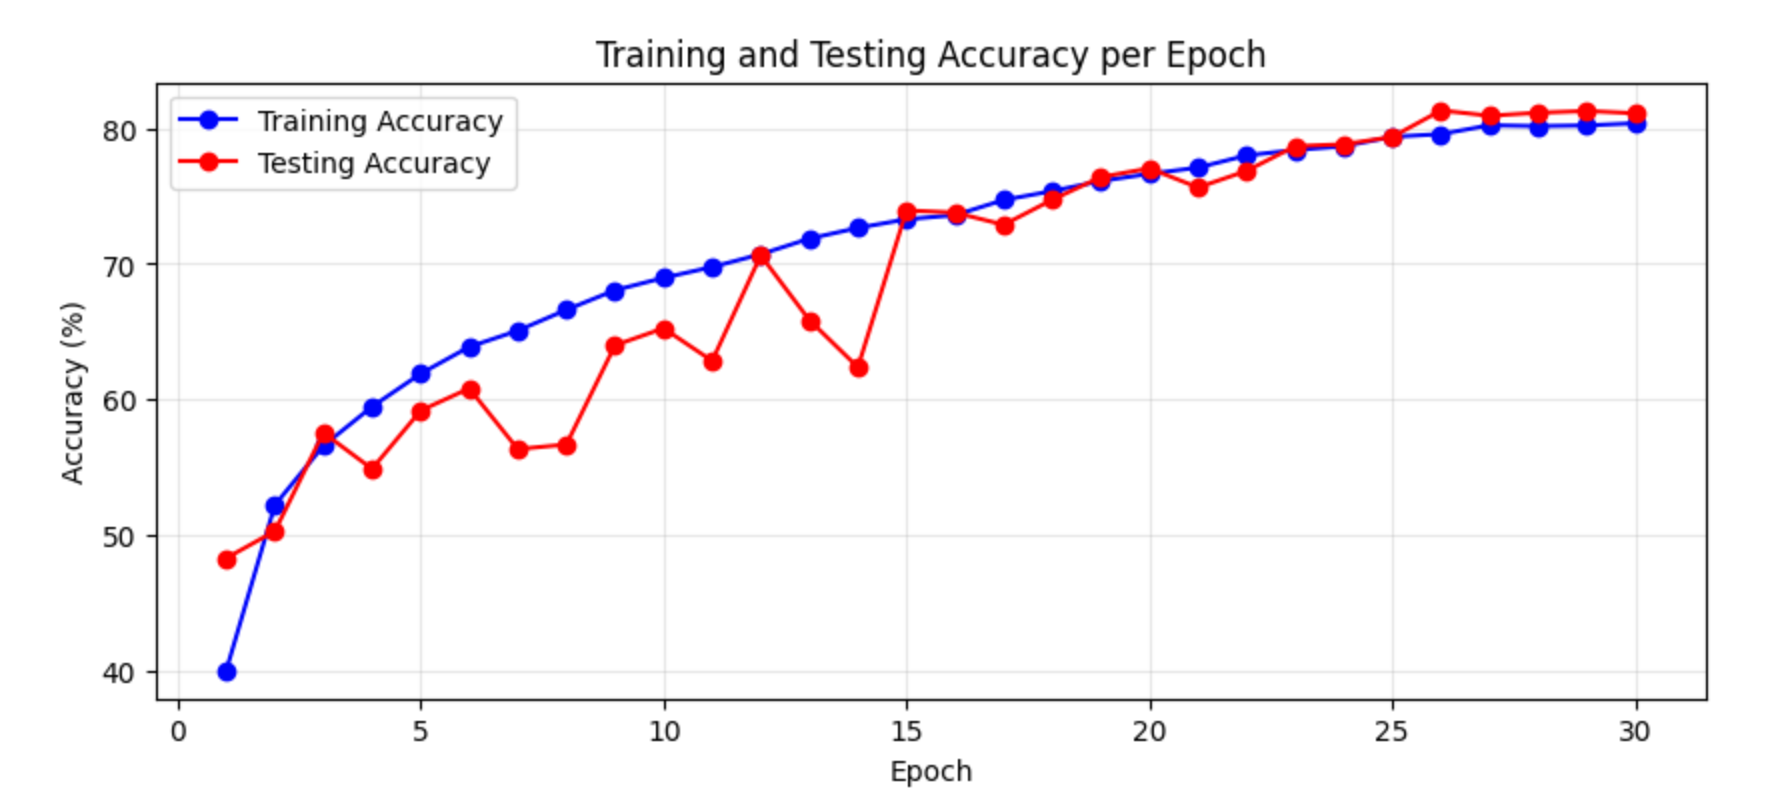

**2.4 Confusion Matrix**

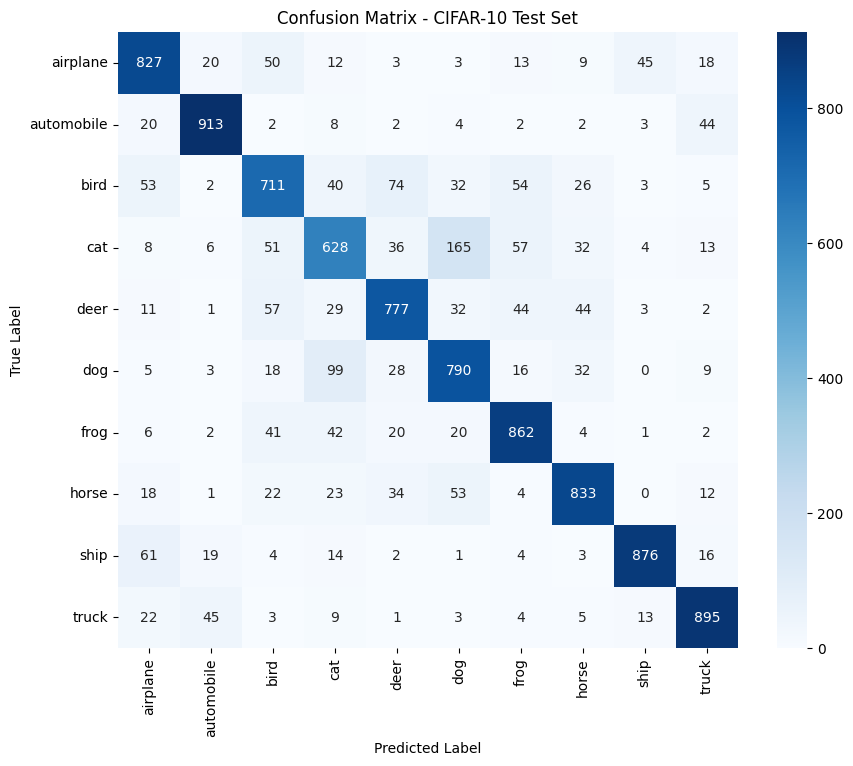

#References

Chauhan, R., Ghanshala, K.K. and Joshi, R.C., 2018, December. Convolutional neural network (CNN) for image detection and recognition. In 2018 first international conference on secure cyber computing and communication (ICSCCC) (pp. 278-282). IEEE.

DeVries, T. and Taylor, G.W., 2017. Improved regularization of convolutional neural networks with cutout. arXiv preprint arXiv:1708.04552.

Dizabadi, N.K., 2026. Empirical Ablation and Ensemble Optimization of a Convolutional Neural Network for CIFAR-10 Classification. arXiv preprint arXiv:2604.23861.

He, K., Zhang, X., Ren, S. and Sun, J., 2016. Deep residual learning for image recognition. In Proceedings of the IEEE conference on computer vision and pattern recognition (pp. 770-778).

Kang, M., 2026. Interpolation between Convolution and Attention via K-Nearest Neighbors. arXiv preprint arXiv:2606.14725.

Krizhevsky, A. and Hinton, G., 2009. Learning multiple layers of features from tiny images.

Loshchilov, I. and Hutter, F., 2016. Sgdr: Stochastic gradient descent with warm restarts. arXiv preprint arXiv:1608.03983.

Salehin, I. and Kang, D.K., 2023. A review on dropout regularization approaches for deep neural networks within the scholarly domain. Electronics, 12(14), p.3106

Shafiq, M. and Gu, Z., 2022. Deep residual learning for image recognition: A survey. Applied sciences, 12(18), p.8972.

Thanapol, P., Lavangnananda, K., Bouvry, P., Pinel, F. and Leprévost, F., 2020, October. Reducing overfitting and improving generalization in training convolutional neural network (CNN) under limited sample sizes in image recognition. In 2020-5th International Conference on Information Technology (InCIT) (pp. 300-305). IEEE.

Xu, Y. (2026) ECS7037P: Neural Networks and Applications. Week 3: Learning and Optimization. Queen Mary University of London